<a href="https://colab.research.google.com/github/sayaka-sugiyama-jp/Social-Capital-and-Disaster-Induced-Eviction-Filings/blob/main/code/2_4_Fig4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Formatting

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import cvxpy as cp
import seaborn as sns
import matplotlib
import statsmodels.api as sm
import matplotlib.gridspec as gridspec

from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import (check_X_y, check_array,check_is_fitted)
from statsmodels.tsa.arima_process import ArmaProcess
from google.colab import files
from google.colab import drive
from matplotlib import pyplot as plt
from cycler import cycler

drive.mount('/mnt/drive', force_remount=True)

Mounted at /mnt/drive


In [2]:
sc_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC_ct.csv")
sc_ct['GEOID'] = sc_ct['TRACT'].astype(str).str.zfill(11).str.replace(r"\.0$", "", regex=True)
HD_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_ct.csv")
HD_ct = HD_ct.dropna(subset=['GEOID']).copy()
HD_ct['GEOID'] = HD_ct['GEOID'].astype(int).astype(str).str.zfill(11)
acs_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_ct.csv")
acs_ct['GEOID'] = acs_ct['GEOID'].astype(str).copy()
sc_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC.csv")
sc_zip = sc_zip.dropna(subset=['zip']).copy()
sc_zip['GEOID'] = sc_zip['zip'].astype(int).astype(str).str.zfill(5)
HD_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_zip.csv")
HD_zip['zipCode'] = HD_zip['zipCode'].astype(str).str.strip()
HD_zip['zipCode_clean'] = HD_zip['zipCode'].str.extract(r'(\d+)', expand=False)
HD_zip = HD_zip.dropna(subset=['zipCode_clean']).copy()
HD_zip['GEOID'] = HD_zip['zipCode_clean'].astype(int).astype(str).str.zfill(5)
acs_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_zip.csv")
acs_zip['GEOID'] = acs_zip['GEOID'].astype(int).astype(str).str.zfill(5)

sc_all = pd.concat([sc_ct, sc_zip])
HD_all = pd.concat([HD_ct[["GEOID", "disasterNumber", "Tre_p"]], HD_zip[["GEOID", "disasterNumber", "Tre_p"]]],ignore_index=True)
acs_all = pd.concat([acs_ct, acs_zip])

In [3]:
df_1 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_ct_filtered.csv")).rename(columns={"FIPS5": "FIPS"})
df_2 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_zip_filtered.csv"))
df_2['state'] = df_2['FIPS'].astype(str).str[0:2]
df_dis =pd.read_csv("/mnt/drive/MyDrive/Colab_data/Disaster.csv")

geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()
geo_city_df['GEOID'] = geo_city_df['GEOID'].astype(str)

In [6]:
# CSV
df_fil_ct = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all.csv").T.iloc[1:]
df_fil_zip = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all_zip.csv").T.iloc[1:]
df_combined = pd.concat([df_fil_ct, df_fil_zip])

df_combined = df_combined.reset_index()
df_combined = df_combined.rename(columns={'index': 'disaster_GEOID'})
df_combined[['disasterNumber', 'GEOID']] = df_combined['disaster_GEOID'].str.split('_', expand=True)

df_combined['disasterNumber'] = df_combined['disasterNumber'].astype(str)
df_combined['GEOID'] = df_combined['GEOID'].astype(str)

cum_df_12 = df_combined[[24,'GEOID','disasterNumber']].copy()
cum_df_12 = cum_df_12.rename(columns={24: 'cum_att'})
cum_df_12["GEOID"] = cum_df_12["GEOID"].astype(str)

In [7]:
# --- Create average filings dictionary ---
avg_dict = df_1.groupby("GEOID")["filings_2020_p2"].mean().to_dict()

cum_df_12["disasterNumber"] = cum_df_12["disasterNumber"].astype(str)
HD_all["disasterNumber"] = HD_all["disasterNumber"].astype(str)

# --- Merge all necessary data ---
merged_df = cum_df_12.merge(sc_all, on="GEOID", how="left") \
                     .merge(HD_all, on=["disasterNumber", "GEOID"], how="left")\
                     .merge(acs_all, on="GEOID", how="left") \
                     .merge(geo_city_df, on="GEOID", how="left")

merged_df = merged_df.rename(columns={"disaster_id": "disaster", "Cumulative_ATT": "cum_att"})

In [8]:
# Get record from FEMA API
url = "https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries?$format=csv&$allrecords=true"

# Make it to dataframe
dec = pd.read_csv(url)

# Make FIPS code
dec['fipsStateCode'] = dec['fipsStateCode'].astype(str).str.zfill(2)
dec['fipsCountyCode'] = dec['fipsCountyCode'].astype(str).str.zfill(3)
dec['FIPS'] = dec['fipsStateCode'] + dec['fipsCountyCode']
dec['FIPS'] = dec['FIPS'].astype(str).copy()

# Get a simpler dec
dec = dec[['disasterNumber', 'state', 'designatedArea', 'fipsStateCode', 'fipsCountyCode', 'FIPS']].copy()
df_disdecall = pd.read_csv("/mnt/drive/MyDrive/Colab_data/DisasterDeclarationsSummaries.csv")

dec = pd.merge(dec, df_disdecall, left_on='disasterNumber', right_on='disasterNumber', how='left').copy()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# ATT Regression

## Normal regression

In [9]:
# --- Remove Inf and drop missing ---
merged_df_clean = merged_df.replace([np.inf, -np.inf], np.nan)

y_clean = merged_df_clean["cum_att"].astype(float)

# Independent variables
merged_df_clean['D_TH'] = merged_df_clean['Tre_p']
merged_df_clean['Black_Population_Ratio'] = merged_df_clean['Black_Population'] / merged_df_clean['Total_Population']
merged_df_clean['zip'] = merged_df_clean['GEOID'].apply(lambda x: 1 if len(str(x)) == 5 else 0)


In [10]:
# =====================================================
# Load RMSPE
# =====================================================

save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"

att_df = pd.read_csv(save_dir + "att_all.csv")

# disaster_id × GEOID ごとに1行だけ残す
rmspe_df = (
    att_df[
        ["disaster_id", "GEOID", "RMSPE"]
    ]
    .drop_duplicates()
)

# 型を合わせる
rmspe_df["disaster_id"] = rmspe_df["disaster_id"].astype(str)
rmspe_df["GEOID"] = rmspe_df["GEOID"].astype(str)

merged_df_clean["disasterNumber"] = (
    merged_df_clean["disasterNumber"]
    .astype(float)
    .astype(int)
    .astype(str)
)

merged_df_clean["GEOID"] = merged_df_clean["GEOID"].astype(str)

# =====================================================
# Merge
# =====================================================

merged_df_clean = merged_df_clean.merge(
    rmspe_df,
    left_on=["disasterNumber", "GEOID"],
    right_on=["disaster_id", "GEOID"],
    how="left"
)

merged_df_clean = merged_df_clean.drop(columns="disaster_id")

print("Matched RMSPE:", merged_df_clean["RMSPE"].notna().sum())
print("Missing RMSPE:", merged_df_clean["RMSPE"].isna().sum())

Matched RMSPE: 2642
Missing RMSPE: 61


In [12]:
merged_df_clean = merged_df_clean[merged_df_clean["city"] != "Richmond, VA"]

In [13]:
x_vars = [
    "civic_organizations_zip",
    "volunteering_rate_zip",
    "nbhd_bias_high_zip",
    "nbhd_bias_zip",
    "bias_grp_mem_high_zip",
    "bias_grp_mem_zip",
    "nbhd_exposure_zip",
    "exposure_grp_mem_high_zip",
    "exposure_grp_mem_zip",
    "ec_grp_mem_high_zip",
    "nbhd_ec_high_zip",
    "ec_high_zip",
    "ec_grp_mem_zip",
    "nbhd_ec_zip",
    "ec_zip"
]

x_vars_plot = [
    "civic_organizations_zip",
    "volunteering_rate_zip",
    "nbhd_exposure_zip",
    "exposure_grp_mem_zip",
    "nbhd_ec_zip",
    "ec_grp_mem_zip",
    "ec_zip"
]


control_vars = [
    "Median_Household_Income",
    "Black_Population_Ratio",
    "Renter_Households",
    "disasterNumber",
    "D_TH"
]

y_var = "cum_att"

In [14]:
print(len(merged_df_clean))

cols = [y_var] + x_vars + control_vars + ["RMSPE"]
merged_df_clean["D_TH"] = merged_df_clean["D_TH"].fillna(0)

print(merged_df_clean[cols].isna().sum().sort_values(ascending=False))

2697
nbhd_bias_zip                637
nbhd_bias_high_zip           637
nbhd_ec_high_zip             637
nbhd_ec_zip                  637
nbhd_exposure_zip            637
bias_grp_mem_high_zip        585
exposure_grp_mem_zip         585
ec_grp_mem_high_zip          585
ec_grp_mem_zip               585
exposure_grp_mem_high_zip    585
bias_grp_mem_zip             585
ec_high_zip                  583
ec_zip                       583
civic_organizations_zip      582
volunteering_rate_zip        582
RMSPE                         55
Median_Household_Income       12
Black_Population_Ratio         1
cum_att                        0
Renter_Households              0
disasterNumber                 0
D_TH                           0
dtype: int64


/tmp/ipykernel_6048/1032542594.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_clean["D_TH"] = merged_df_clean["D_TH"].fillna(0)


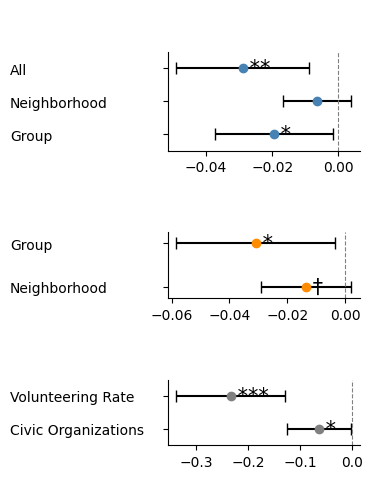

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
x_label_mapping = {
    "civic_organizations_zip": "Civic Organizations",
    "volunteering_rate_zip": "Volunteering Rate",
    "nbhd_bias_high_zip": "Neighborhood Friending Bias (high SE)",
    "nbhd_bias_zip": "Neighborhood\n Friending Bias",
    "bias_grp_mem_high_zip": "Group Friending Bias (high SE)",
    "bias_grp_mem_zip": "Group Friending Bias",
    "nbhd_exposure_zip": "Neighborhood",
    "exposure_grp_mem_high_zip": "Group Exposure (high SE)",
    "exposure_grp_mem_zip": "Group",
    "ec_grp_mem_high_zip": "Group Econ Connectedness (high SE)",
    "nbhd_ec_high_zip": "Neighborhood Econ Connectedness (high SE)",
    "ec_high_zip": "Economic Connectedness (high SE)",
    "nbhd_ec_zip": "Neighborhood",
    "ec_grp_mem_zip": "Group",
    "ec_zip": "All",
}

# --- Category ---
def get_category(var_name):
    if "ec" in var_name:
        return "economic connectedness"
    elif "exposure" in var_name:
        return "exposure"
    elif "bias" in var_name:
        return "friending bias"
    else:
        return "civic engagement"

color_mapping = {
    "economic connectedness": "steelblue",
    "exposure": "darkorange",
    "friending bias": "seagreen",
    "civic engagement": "grey"
}

# ==============================
# Regression
# ==============================
def run_regression(
    df,
    vars_list,
    controls,
    y_var="cum_att",
    cluster_var="disasterNumber"
):
    results = []
    regression_results = {}
    latex_results = {}

    for x in vars_list:
        # =========================
        # Subset
        # =========================
        cols = [y_var, x] + controls
        df_sub = df[cols].copy()

        # =========================
        # numeric coercion
        # =========================
        df_sub[y_var] = pd.to_numeric(df_sub[y_var], errors="coerce")
        df_sub[x] = pd.to_numeric(df_sub[x], errors="coerce")

        df_sub = (
            df_sub
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        # =========================
        # y / X
        # =========================
        y = df_sub[y_var].astype(float)
        X = df_sub.drop(columns=[y_var])

        # =========================
        # Explicit FE handling
        # =========================
        if "disasterNumber" in X.columns:
            X["disasterNumber"] = X["disasterNumber"].astype("category")

        if "zip" in X.columns:
            X["zip"] = X["zip"].astype("category")

        # =========================
        # Dummy
        # =========================
        X = pd.get_dummies(X, drop_first=True)

        X = X.astype(float)

        X = sm.add_constant(X, has_constant="add")

        # =========================
        # Cluster
        # =========================
        groups = df_sub[cluster_var]

        model = sm.OLS(y, X).fit(
            cov_type="cluster",
            cov_kwds={"groups": groups}
        )
        regression_results[x] = model

        latex_results[x] = {
            "model": model,
            "nobs": int(model.nobs),
            "r2": model.rsquared
        }

        results.append({
            "x_variable": x,
            "Coefficient": model.params[x],
            "CI_Lower": model.conf_int().loc[x, 0],
            "CI_Upper": model.conf_int().loc[x, 1],
            "p_value": model.pvalues[x]
        })

    return pd.DataFrame(results),regression_results, latex_results


# --- Plot ---
def plot_coefficients_by_category(df):
    df["category"] = df["x_variable"].apply(get_category)
    categories = list(df["category"].unique())[::-1]

    height_ratios = [len(df[df["category"] == cat]) for cat in categories]

    global_min = df["CI_Lower"].min()-0.05
    global_max = df["CI_Upper"].max()+0.05

    fig = plt.figure(figsize=(3.8, sum(height_ratios)*0.7))
    gs = gridspec.GridSpec(len(categories), 1, height_ratios=height_ratios)

    for idx, cat in enumerate(categories):
        ax = fig.add_subplot(gs[idx])
        sub_df = df[df["category"] == cat]

        for i, row in sub_df.iterrows():
            color = color_mapping.get(cat, "black")
            ci_lower = row["Coefficient"] - row["CI_Lower"]
            ci_upper = row["CI_Upper"] - row["Coefficient"]

            # significance star
            if row["p_value"] < 0.001:
                signif = "***"
            elif row["p_value"] < 0.01:
                signif = "**"
            elif row["p_value"] < 0.05:
                signif = "*"
            elif row["p_value"] < 0.1:
                signif = "†"
            else:
                signif = ""

            ax.errorbar(
                row["Coefficient"], i,
                xerr=[[ci_lower], [ci_upper]],
                fmt="o", color=color, ecolor="black",
                capsize=4, markersize=6
            )

            if signif:
                ax.text(row["Coefficient"], i, " " + signif,
                        va="center", fontsize=15)

        ax.set_title(cat.capitalize(), fontsize=1, color="white", loc = "left", pad = 30)
        ax.set_yticks(sub_df.index)
        ax.set_yticklabels([x_label_mapping.get(v, v) for v in sub_df["x_variable"]],fontsize=10,ha="left")
        ax.tick_params(axis='y', pad=110)


        ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)

        ymin = sub_df.index.min() - 0.5
        ymax = sub_df.index.max() + 0.5
        ax.set_ylim(ymin, ymax)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)


    plt.tight_layout()
    plt.savefig("figure.png", dpi=200, bbox_inches="tight")
    plt.show()

df_controls, regression_results, latex_results = run_regression(
    merged_df_clean,
    x_vars,
    controls=control_vars
)
coef_df_plot = df_controls[df_controls["x_variable"].isin(x_vars_plot)].copy()

plot_coefficients_by_category(coef_df_plot)

from google.colab import files
files.download("figure.png")

In [16]:
for var, model in regression_results.items():
    print("=" * 80)
    print(var)
    print(model.summary())


civic_organizations_zip
                            OLS Regression Results                            
Dep. Variable:                cum_att   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     2.536
Date:                Fri, 03 Jul 2026   Prob (F-statistic):             0.0866
Time:                        12:41:03   Log-Likelihood:                 3867.8
No. Observations:                2110   AIC:                            -7700.
Df Residuals:                    2092   BIC:                            -7598.
Df Model:                          17                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
co

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/loc

                            OLS Regression Results                            
Dep. Variable:                cum_att   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     1.783
Date:                Fri, 03 Jul 2026   Prob (F-statistic):              0.191
Time:                        12:41:03   Log-Likelihood:                 3870.9
No. Observations:                2107   AIC:                            -7706.
Df Residuals:                    2089   BIC:                            -7604.
Df Model:                          17                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/loc

## Regression with placebo variance

   disaster_id  placebo_GEOID     RMSPE  cumATT12
0         4735    47037016800  0.000108 -0.001897
1         4735    47037015806  0.003291  0.015358
2         4735    47037010601  0.002388  0.008602
3         4735    47037017200  0.001237  0.018158
4         4735    47037015618  0.001784 -0.021070

Summary of placebo variance


,placebo_var,placebo_sd,n_placebo
count,1678.000000,1678.000000,2697.000000
mean,0.001130,0.029695,25.563589
std,0.001395,0.015754,24.908835
min,0.000000,0.000000,0.000000
25%,0.000520,0.022806,4.000000
50%,0.000756,0.027489,23.000000
75%,0.001389,0.037274,40.000000
max,0.018458,0.135862,100.000000



Observations with enough placebo: 1678
Total observations: 2697


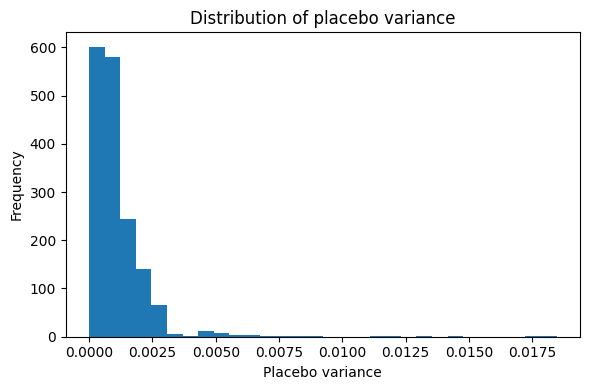

In [17]:
import numpy as np
import pandas as pd

# =====================================================
# Load placebo library
# =====================================================

save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"
placebo_library = pd.read_csv(
    save_dir + "placebo_library.csv"
)

print(placebo_library.head())

# =====================================================
# Parameters
# =====================================================

LOWER = 0.5
UPPER = 2.0
MIN_PLACEBO = 10
EPS = 1e-6

# =====================================================
# Compute placebo variance for each treated tract
# =====================================================

placebo_var_list = []

for _, row in merged_df_clean.iterrows():

    disaster = str(row["disasterNumber"])
    rmspe = row["RMSPE"]

    # -----------------------------
    # Same disaster
    # -----------------------------
    subset = placebo_library[
        placebo_library["disaster_id"].astype(str) == disaster
    ].copy()

    # -----------------------------
    # RMSPE filter
    # -----------------------------
    subset = subset[
        (subset["RMSPE"] >= LOWER * rmspe) &
        (subset["RMSPE"] <= UPPER * rmspe)
    ]

    n_placebo = len(subset)

    if n_placebo < MIN_PLACEBO:

        placebo_var = np.nan
        placebo_sd = np.nan

    else:

        placebo_var = subset["cumATT12"].var(ddof=1)

        placebo_sd = np.sqrt(placebo_var)

    placebo_var_list.append({

        "placebo_var": placebo_var,

        "placebo_sd": placebo_sd,

        "n_placebo": n_placebo

    })

# =====================================================
# Merge
# =====================================================

placebo_var_df = pd.DataFrame(placebo_var_list)

merged_df_clean = merged_df_clean.drop(
    columns=["placebo_var", "placebo_sd", "n_placebo"],
    errors="ignore"
)

merged_df_clean = pd.concat(
    [
        merged_df_clean.reset_index(drop=True),
        placebo_var_df
    ],
    axis=1
)

# =====================================================
# Summary
# =====================================================

print("\nSummary of placebo variance")

display(

    merged_df_clean[
        [
            "placebo_var",
            "placebo_sd",
            "n_placebo"
        ]
    ].describe()

)

print(
    "\nObservations with enough placebo:",
    (merged_df_clean["n_placebo"] >= MIN_PLACEBO).sum()
)

print(
    "Total observations:",
    len(merged_df_clean)
)

# =====================================================
# Histogram
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(
    merged_df_clean["placebo_var"].dropna(),
    bins=30
)

plt.xlabel("Placebo variance")

plt.ylabel("Frequency")

plt.title("Distribution of placebo variance")

plt.tight_layout()

plt.show()

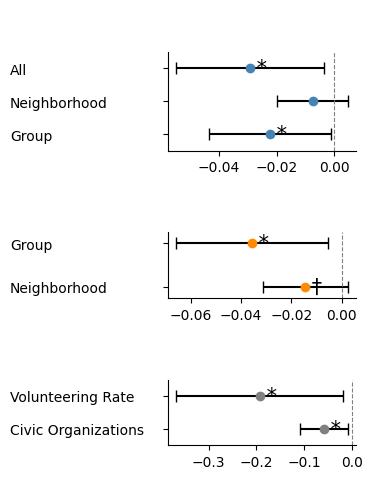

<Figure size 640x480 with 0 Axes>

In [18]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==============================
# IVW Regression
# ==============================

def run_ivw_regression(
    df,
    vars_list,
    controls,
    y_var="cum_att",
    weight_var="placebo_var",
    eps=1e-6
):

    results = []
    regression_results = {}
    latex_results = {}

    for x in vars_list:

        cols = [y_var, x] + controls + [weight_var]

        df_sub = df[cols].copy()

        # ------------------------------------
        # remove missing placebo variance
        # ------------------------------------

        df_sub = (
            df_sub
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        df_sub = df_sub[
            df_sub[weight_var] > 0
        ].copy()

        # ------------------------------------
        # inverse variance weight
        # ------------------------------------

        df_sub["weight"] = 1 / (
            df_sub[weight_var] + eps
        )

        # optional:
        # trim extreme weights

        upper = df_sub["weight"].quantile(0.99)

        lower = df_sub["weight"].quantile(0.01)

        df_sub["weight"] = df_sub["weight"].clip(
            lower=lower,
            upper=upper
        )

        # ------------------------------------

        y = pd.to_numeric(
            df_sub[y_var]
        )

        X = df_sub.drop(
            columns=[
                y_var,
                weight_var,
                "weight"
            ]
        )

        if "disasterNumber" in X.columns:
            X["disasterNumber"] = (
                X["disasterNumber"]
                .astype("category")
            )

        if "zip" in X.columns:
            X["zip"] = (
                X["zip"]
                .astype("category")
            )

        X = pd.get_dummies(
            X,
            drop_first=True
        )

        X = X.astype(float)

        X = sm.add_constant(
            X,
            has_constant="add"
        )

        # ------------------------------------
        # Clustered WLS
        # ------------------------------------

        groups = df_sub["disasterNumber"]

        model = sm.WLS(
            y,
            X,
            weights=df_sub["weight"]
        ).fit(
            cov_type="cluster",
            cov_kwds={
                "groups": groups
            }
        )

        regression_results[x] = model

        latex_results[x] = {
            "model": model,
            "nobs": int(model.nobs),
            "r2": model.rsquared
        }

        ci = model.conf_int()

        results.append({

            "x_variable": x,

            "Coefficient": model.params[x],

            "CI_Lower": ci.loc[x, 0],

            "CI_Upper": ci.loc[x, 1],

            "p_value": model.pvalues[x]

        })

    return (
        pd.DataFrame(results),
        regression_results,
        latex_results
    )


# ===================================
# Run
# ===================================

df_controls_ivw, regression_results_ivw, latex_results_ivw = run_ivw_regression(
    merged_df_clean,
    x_vars,
    control_vars
)

coef_df_plot = df_controls_ivw[
    df_controls_ivw["x_variable"].isin(
        x_vars_plot
    )
].copy()

plot_coefficients_by_category(
    coef_df_plot
)

plt.tight_layout()

plt.savefig(
    "figure_IVW.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files

#files.download("figure_IVW.png")

In [19]:
for var, model in regression_results_ivw.items():
    print("=" * 80)
    print(var)
    print(model.summary())


civic_organizations_zip
                            WLS Regression Results                            
Dep. Variable:                cum_att   R-squared:                       0.098
Model:                            WLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     1607.
Date:                Fri, 03 Jul 2026   Prob (F-statistic):           3.48e-14
Time:                        12:41:10   Log-Likelihood:                 2203.8
No. Observations:                1195   AIC:                            -4376.
Df Residuals:                    1179   BIC:                            -4294.
Df Model:                          15                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
co

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/loc

##Spatial regression

In [20]:
# ============================================================
# Moran's I of OLS residuals (all regressions)
# ============================================================

!pip -q install libpysal esda geopandas

import geopandas as gpd
import pandas as pd
import numpy as np
import statsmodels.api as sm

from glob import glob
import os
import zipfile

from libpysal.weights import Queen
from esda.moran import Moran

# -------------------------------------------------------
# Read tract shapefiles
# -------------------------------------------------------

base_dir = "/mnt/drive/MyDrive/Colab_data"

zip_files = glob(os.path.join(base_dir, "*.zip"))

for z in zip_files:
    with zipfile.ZipFile(z, "r") as zip_ref:
        zip_ref.extractall(base_dir)

shapefiles = (
    glob(os.path.join(base_dir, "tl_2021_*_tract.shp"))
    + glob(os.path.join(base_dir, "tl_2022_*_tract.shp"))
)

gdfs = [gpd.read_file(shp) for shp in shapefiles]

tracts = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs=gdfs[0].crs
)

tracts["GEOID"] = tracts["GEOID"].astype(str)

# -------------------------------------------------------
# Moran's I for each regression
# -------------------------------------------------------

results = []

for x in x_vars:

    print(f"Running {x}...")

    cols = [y_var, x] + control_vars + ["GEOID"]

    df_sub = merged_df_clean[cols].copy()

    df_sub[y_var] = pd.to_numeric(df_sub[y_var], errors="coerce")
    df_sub[x] = pd.to_numeric(df_sub[x], errors="coerce")

    df_sub = (
        df_sub
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    # tract only
    df_sub = df_sub[df_sub["GEOID"].str.len() == 11].copy()

    y = df_sub[y_var].astype(float)

    X = df_sub.drop(columns=[y_var, "GEOID"])

    if "disasterNumber" in X.columns:
        X["disasterNumber"] = X["disasterNumber"].astype("category")

    if "zip" in X.columns:
        X["zip"] = X["zip"].astype("category")

    X = pd.get_dummies(X, drop_first=True)
    X = X.astype(float)
    X = sm.add_constant(X)

    groups = df_sub["disasterNumber"]

    model = sm.OLS(y, X).fit(
        cov_type="cluster",
        cov_kwds={"groups": groups}
    )

    df_sub["residual"] = model.resid.values

    # merge shapefile
    gdf = tracts.merge(
        df_sub[["GEOID", "residual"]],
        on="GEOID",
        how="inner"
    )

    # Queen weights
    w = Queen.from_dataframe(gdf)

    # remove islands
    if len(w.islands) > 0:
        gdf = gdf.drop(index=w.islands).reset_index(drop=True)
        w = Queen.from_dataframe(gdf)

    w.transform = "R"

    moran = Moran(
        gdf["residual"].values,
        w,
        permutations=9999
    )

    results.append({
        "Variable": x,
        "N": len(gdf),
        "Moran_I": moran.I,
        "Expected_I": moran.EI,
        "Z": moran.z_sim,
        "P_value": moran.p_sim
    })

# -------------------------------------------------------
# Results
# -------------------------------------------------------

moran_results = (
    pd.DataFrame(results)
    .sort_values("P_value")
    .reset_index(drop=True)
)

print("\n================ Moran's I of OLS Residuals ================\n")
display(moran_results)

Running civic_organizations_zip...


/tmp/ipykernel_6048/972147342.py:102: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 26 disconnected components.
 There are 5 islands with ids: 156, 1929, 1934, 1937, 1943.
  W.__init__(self, neighbors, ids=ids, **kw)
/tmp/ipykernel_6048/972147342.py:107: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 21 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


Running volunteering_rate_zip...


/tmp/ipykernel_6048/972147342.py:102: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 26 disconnected components.
 There are 5 islands with ids: 156, 1929, 1934, 1937, 1943.
  W.__init__(self, neighbors, ids=ids, **kw)
/tmp/ipykernel_6048/972147342.py:107: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 21 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


Running nbhd_bias_high_zip...


...

/tmp/ipykernel_6048/972147342.py:102: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 27 disconnected components.
 There are 6 islands with ids: 59, 151, 1914, 1916, 1926, 1978.
  W.__init__(self, neighbors, ids=ids, **kw)
/tmp/ipykernel_6048/972147342.py:107: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 21 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


Running ec_zip...


/tmp/ipykernel_6048/972147342.py:102: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 26 disconnected components.
 There are 5 islands with ids: 156, 1929, 1934, 1937, 1943.
  W.__init__(self, neighbors, ids=ids, **kw)
/tmp/ipykernel_6048/972147342.py:107: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 21 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)



================ Moran's I of OLS Residuals ================



,Variable,N,Moran_I,Expected_I,Z,P_value
0,volunteering_rate_zip,2051,0.088088,-0.000488,6.766533,0.0001
1,nbhd_bias_high_zip,2001,0.092576,-0.000500,7.173470,0.0001
2,nbhd_bias_zip,2001,0.089963,-0.000500,6.989945,0.0001
3,bias_grp_mem_high_zip,2050,0.091273,-0.000488,7.139855,0.0001
4,nbhd_exposure_zip,2001,0.087272,-0.000500,6.661818,0.0001
5,bias_grp_mem_zip,2050,0.095511,-0.000488,7.452018,0.0001
6,exposure_grp_mem_high_zip,2050,0.084540,-0.000488,6.454157,0.0001
7,exposure_grp_mem_zip,2050,0.089109,-0.000488,6.872465,0.0001
8,ec_grp_mem_zip,2050,0.091349,-0.000488,7.008328,0.0001
9,ec_grp_mem_high_zip,2050,0.086794,-0.000488,6.656927,0.0001


In [21]:
# ==========================================================
# Spatial Lag Model (SLM) and Spatial Error Model (SEM)
# ==========================================================

!pip -q install spreg libpysal geopandas

import pandas as pd
import numpy as np

from libpysal.weights import Queen

from spreg import ML_Lag
from spreg import ML_Error

# -----------------------------
# Weight matrix
# -----------------------------

tracts["GEOID"] = tracts["GEOID"].astype(str)

results=[]

for x in x_vars:

    print(f"Running {x}")

    cols=[y_var,x]+control_vars+["GEOID"]

    df_sub=merged_df_clean[cols].copy()

    df_sub=df_sub.replace([np.inf,-np.inf],np.nan).dropna()

    df_sub=df_sub[df_sub["GEOID"].str.len()==11].copy()

    gdf=tracts.merge(df_sub,on="GEOID")

    w=Queen.from_dataframe(gdf)

    if len(w.islands)>0:

        gdf=gdf.drop(index=w.islands).reset_index(drop=True)

        w=Queen.from_dataframe(gdf)

    w.transform="R"

    y=gdf[[y_var]].values

    X = gdf[[x] + control_vars].copy()

    X["disasterNumber"]=X["disasterNumber"].astype("category")

    X=pd.get_dummies(
        X,
        columns=["disasterNumber"],
        drop_first=True
    )

    X=X.astype(float)

    xnames=list(X.columns)

    X=X.values

    # -----------------------------
    # Spatial Lag
    # -----------------------------

    slm=ML_Lag(
        y,
        X,
        w=w,
        name_y=y_var,
        name_x=xnames
    )

    # -----------------------------
    # Spatial Error
    # -----------------------------

    sem=ML_Error(
        y,
        X,
        w=w,
        name_y=y_var,
        name_x=xnames
    )

    idx=xnames.index(x)

    results.append({

        "Variable":x,

        "SLM_coef":slm.betas[idx+1][0],
        "SLM_se":slm.std_err[idx+1],
        "SLM_p":slm.z_stat[idx+1][1],

        "SEM_coef":sem.betas[idx+1][0],
        "SEM_se":sem.std_err[idx+1],
        "SEM_p":sem.z_stat[idx+1][1],

        "rho":slm.rho,
        "lambda":sem.lam

    })

results=pd.DataFrame(results)

display(results)

Running civic_organizations_zip


/tmp/ipykernel_6048/2838221869.py:37: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w=Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 26 disconnected components.
 There are 5 islands with ids: 156, 1929, 1934, 1937, 1943.
  W.__init__(self, neighbors, ids=ids, **kw)
/tmp/ipykernel_6048/2838221869.py:43: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w=Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 21 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


ML_Lag


/usr/local/lib/python3.12/dist-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


ML_Error
Running volunteering_rate_zip


...

/tmp/ipykernel_6048/2838221869.py:37: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w=Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 26 disconnected components.
 There are 5 islands with ids: 156, 1929, 1934, 1937, 1943.
  W.__init__(self, neighbors, ids=ids, **kw)
/tmp/ipykernel_6048/2838221869.py:43: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w=Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 21 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


ML_Lag


/usr/local/lib/python3.12/dist-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


ML_Error


,Variable,SLM_coef,SLM_se,SLM_p,SEM_coef,SEM_se,SEM_p,rho,lambda
0,civic_organizations_zip,-0.059084,0.048157,0.219858,-0.055658,0.054933,0.310966,0.244390,0.232710
1,volunteering_rate_zip,-0.188236,0.051869,0.000284,-0.234237,0.061712,0.000147,0.230823,0.220242
2,nbhd_bias_high_zip,-0.004261,0.004844,0.378957,-0.005954,0.005809,0.305438,0.245729,0.236335
3,nbhd_bias_zip,-0.008792,0.006227,0.157955,-0.008736,0.007477,0.242672,0.243403,0.231887
4,bias_grp_mem_high_zip,-0.071764,0.040206,0.074275,-0.071048,0.047594,0.135494,0.241585,0.228861
5,bias_grp_mem_zip,0.008222,0.011725,0.483142,0.013336,0.013797,0.333759,0.245476,0.235704
6,nbhd_exposure_zip,-0.012147,0.003836,0.001541,-0.014939,0.004432,0.000750,0.233822,0.225240
7,exposure_grp_mem_high_zip,-0.029377,0.006863,0.000019,-0.036294,0.008036,0.000006,0.223303,0.213133
8,exposure_grp_mem_zip,-0.027204,0.007642,0.000371,-0.033601,0.008752,0.000124,0.230850,0.222466
9,ec_grp_mem_high_zip,-0.022567,0.005885,0.000126,-0.027960,0.006892,0.000050,0.227714,0.217786


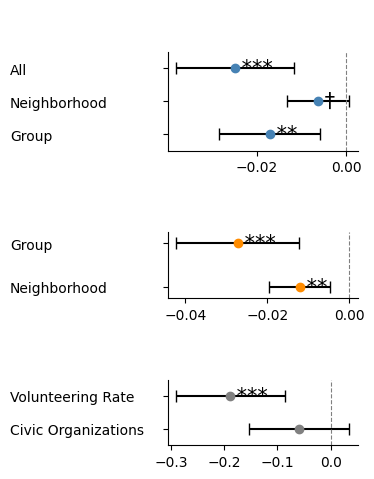

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
slm_plot = results.copy()

slm_plot["x_variable"] = slm_plot["Variable"]
slm_plot["Coefficient"] = slm_plot["SLM_coef"]
slm_plot["CI_Lower"] = slm_plot["SLM_coef"] - 1.96 * slm_plot["SLM_se"]
slm_plot["CI_Upper"] = slm_plot["SLM_coef"] + 1.96 * slm_plot["SLM_se"]
slm_plot["p_value"] = slm_plot["SLM_p"]

coef_df_plot = slm_plot[
    slm_plot["x_variable"].isin(x_vars_plot)
].copy()

plot_coefficients_by_category(coef_df_plot)

from google.colab import files
files.download("figure.png")

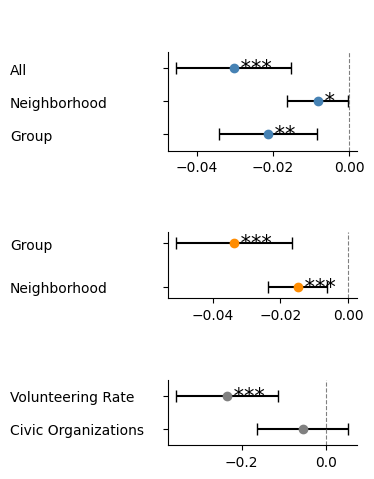

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
sem_plot = results.copy()

sem_plot["x_variable"] = sem_plot["Variable"]
sem_plot["Coefficient"] = sem_plot["SEM_coef"]
sem_plot["CI_Lower"] = sem_plot["SEM_coef"] - 1.96 * sem_plot["SEM_se"]
sem_plot["CI_Upper"] = sem_plot["SEM_coef"] + 1.96 * sem_plot["SEM_se"]
sem_plot["p_value"] = sem_plot["SEM_p"]

coef_df_plot = sem_plot[
    sem_plot["x_variable"].isin(x_vars_plot)
].copy()

plot_coefficients_by_category(coef_df_plot)

from google.colab import files
files.download("figure.png")

In [24]:
use_cols = x_vars + control_vars + [y_var]

df_used = merged_df_clean[use_cols].copy()

df_used = df_used.dropna(subset=control_vars)

desc_stats = df_used.describe()

desc_stats_t = desc_stats.T.iloc[::-1]

latex_table = desc_stats_t.to_latex(float_format="%.3f", index=True)

print(latex_table)

\begin{tabular}{lrrrrrrrr}
\toprule
 & count & mean & std & min & 25% & 50% & 75% & max \\
\midrule
cum_att & 2685.000 & -0.013 & 0.041 & -0.188 & -0.033 & -0.013 & 0.004 & 0.431 \\
D_TH & 2685.000 & 0.002 & 0.010 & 0.000 & 0.000 & 0.000 & 0.000 & 0.112 \\
Renter_Households & 2685.000 & 971.788 & 2185.022 & 0.000 & 377.000 & 630.000 & 1004.000 & 29069.000 \\
Black_Population_Ratio & 2685.000 & 0.286 & 0.293 & 0.000 & 0.053 & 0.168 & 0.424 & 1.000 \\
Median_Household_Income & 2685.000 & 69011.150 & 35487.081 & 2499.000 & 44671.000 & 61250.000 & 85183.000 & 250001.000 \\
ec_zip & 2109.000 & 0.773 & 0.233 & 0.357 & 0.596 & 0.755 & 0.925 & 1.500 \\
nbhd_ec_zip & 2055.000 & 0.696 & 0.391 & 0.095 & 0.395 & 0.637 & 0.934 & 1.869 \\
ec_grp_mem_zip & 2107.000 & 0.845 & 0.278 & 0.282 & 0.642 & 0.833 & 1.018 & 1.632 \\
ec_high_zip & 2109.000 & 1.338 & 0.238 & 0.713 & 1.209 & 1.355 & 1.507 & 1.826 \\
nbhd_ec_high_zip & 2055.000 & 1.183 & 0.415 & 0.233 & 0.917 & 1.216 & 1.500 & 1.937 \\
ec_grp_mem_

In [25]:
pip install stargazer

# Shapley R^2

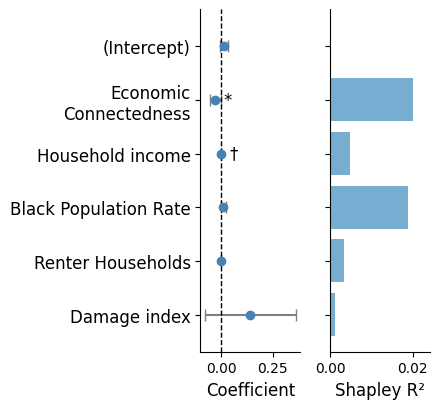

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from collections import defaultdict

# -----------------------------
# 1. Stars
# -----------------------------
def significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.1:
        return "†"
    else:
        return ""

# -----------------------------
# 2. Labels（この変数だけ表示）
# -----------------------------
var_labels = {
    "const": "(Intercept)",
    "ec_zip": "Economic\nConnectedness",
    "Black_Population_Ratio": "Black Population Rate",
    "Renter_Households": "Renter Households",
    "D_TH": "Damage index",
    "Median_Household_Income": "Household income",
}

vars_to_keep = list(var_labels.keys())

# -----------------------------
# 3. Model
# -----------------------------
model = regression_results_ivw["ec_zip"]

coefs = model.params.copy()
conf_int = model.conf_int()
pvals = model.pvalues

# var_labels vars only
coefs = coefs.loc[coefs.index.intersection(vars_to_keep)]
conf_int = conf_int.loc[coefs.index]
pvals = pvals.loc[coefs.index]

coef_names = [var_labels[v] for v in coefs.index]
coef_values = coefs.values
lower = coef_values - conf_int[0].values
upper = conf_int[1].values - coef_values
signif_labels = [significance_stars(p) for p in pvals]

# -----------------------------
# 4. Shapley R²
# -----------------------------
X_full = model.model.exog
y = model.model.endog
exog_names = model.model.exog_names

keep_idx = [
    i for i, v in enumerate(exog_names)
    if (v in vars_to_keep)
]

X = X_full[:, keep_idx]
vars_kept = [exog_names[i] for i in keep_idx]

shapley_r2 = defaultdict(float)
n_samples = 1000
np.random.seed(0)

for _ in range(n_samples):
    perm = np.random.permutation(len(vars_kept))
    current_X = np.ones((len(y), 1))
    r2_prev = 0

    for idx in perm:
        current_X = np.column_stack([current_X, X[:, idx]])
        r2_curr = sm.OLS(y, current_X).fit().rsquared
        shapley_r2[vars_kept[idx]] += r2_curr - r2_prev
        r2_prev = r2_curr

for k in shapley_r2:
    shapley_r2[k] /= n_samples

shapley_r2_list = [
    0 if v == "const" else shapley_r2.get(v, 0)
    for v in coefs.index
]

# -----------------------------
# 5. Plot
# -----------------------------
fig, (ax_coef, ax_r2) = plt.subplots(
    ncols=2, sharey=True,
    figsize=(4.5, len(coef_names) * 0.7)
)

y_pos = np.arange(len(coef_names))

# Coefficients
ax_coef.errorbar(
    coef_values, y_pos,
    xerr=[lower, upper],
    fmt='o', color='steelblue',
    ecolor='gray', capsize=4
)
ax_coef.axvline(0, color='black', linestyle='--', linewidth=1)

for i, s in enumerate(signif_labels):
    if s:
        offset = 0.04
        ax_coef.text(
            coef_values[i] + offset,
            i,
            s,
            va='center',
            fontsize=12
        )

ax_coef.set_xlabel("Coefficient", fontsize=12)
ax_coef.set_yticks(y_pos)
ax_coef.set_yticklabels(coef_names, fontsize=12)
ax_coef.invert_yaxis()
ax_coef.spines['top'].set_visible(False)
ax_coef.spines['right'].set_visible(False)

# Shapley R²
ax_r2.barh(y_pos, shapley_r2_list, alpha=0.6)
ax_r2.set_xlabel("Shapley R²", fontsize=12)
ax_r2.set_xlim(
    0,
    max(shapley_r2_list) * 1.2 if max(shapley_r2_list) > 0 else 0.01
)
ax_r2.spines['top'].set_visible(False)
ax_r2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("figure.png", dpi=200)
plt.show()

from google.colab import files
files.download("figure.png")


#TEX

In [29]:
from statsmodels.iolib.summary2 import summary_col
import re
import math

# ==================================================
# 1. Variable groups
# ==================================================
demographics_vars = {
    "Median_Household_Income",
    "Black_Population_Ratio",
    "Renter_Households",
}

damage_index_vars = {
    "D_TH",
}

disaster_fe_prefix = "disaster"

# ==================================================
# 2. Label mapping（表示したい変数のみ）
# ==================================================
x_label_mapping = {
    "civic_organizations_zip": "Civic Orgs",
    "volunteering_rate_zip": "Volunteering Rate",
    "nbhd_bias_high_zip": "Neighborhood Bias (high)",
    "nbhd_bias_zip": "Neighborhood Bias",
    "bias_grp_mem_high_zip": "Group Bias (high)",
    "bias_grp_mem_zip": "Group Bias",
    "nbhd_exposure_zip": "Neighborhood Exp.",
    "exposure_grp_mem_high_zip": "Group Exp. (high)",
    "exposure_grp_mem_zip": "Group Exp.",
    "ec_grp_mem_high_zip": "Group EC (high)",
    "nbhd_ec_high_zip": "Neighborhood EC (high)",
    "ec_high_zip": "EC (high)",
    "nbhd_ec_zip": "Neighborhood EC",
    "ec_grp_mem_zip": "Group EC",
    "ec_zip": "EC",
    "const": "const"
}

target_vars = list(x_label_mapping.keys())

# ==================================================
# 3. Helper functions
# ==================================================
def has_any(model, vars_set):
    return any(v in model.model.exog_names for v in vars_set)

def has_prefix(model, prefix):
    return any(v.startswith(prefix) for v in model.model.exog_names)

# ==================================================
# 4. Build LaTeX table
# ==================================================
def format_latex_table(models, start_idx):

    table = summary_col(
        models,
        stars=True,
        model_names=[f"({i})" for i in range(start_idx, start_idx + len(models))],
        info_dict={
            "Damage index": lambda x: "Yes" if has_any(x, damage_index_vars) else "No",
            "Demographics": lambda x: "Yes" if has_any(x, demographics_vars) else "No",
            "Disaster FE": lambda x: "Yes" if has_prefix(x, disaster_fe_prefix) else "No",
            "N": lambda x: f"{int(x.nobs)}",
            "R-squared": lambda x: f"{x.rsquared:.3f}",
        },
    )

    df = table.tables[0]

    # ----------------------------------------------
    # ① 残す係数＋SE行、集計行を position で決める
    # ----------------------------------------------
    keep_pos = set()
    n = len(df)
    summary_rows = {"R-squared", "R-squared Adj.", "N", "Damage index", "Demographics", "Disaster FE"}

    for i in range(n):
        idx = df.index[i]
        base = re.sub(r"\(.*\)", "", idx).strip()

        # 表示したい変数の係数行
        if base in target_vars:
            keep_pos.add(i)
            if i + 1 < n:
                keep_pos.add(i + 1)  # SE行も保持
        # 集計行は必ず保持
        elif base in summary_rows:
            keep_pos.add(i)

    df = df.iloc[sorted(keep_pos)]

    # ----------------------------------------------
    # ② index をラベルに置換（SE行対応）
    # ----------------------------------------------
    new_index = []
    last_label = ""

    for idx in df.index:
        base = re.sub(r"\(.*\)", "", idx).strip()

        if base in x_label_mapping:
            label = x_label_mapping[base]
            last_label = label
        else:
            # SE 行や集計行は index が空でも保持
            if "(" in idx:
                label = f"{last_label} {idx}"
            else:
                label = base

        new_index.append(label)

    df.index = new_index

    # ----------------------------------------------
    # ③ LaTeX 化
    # ----------------------------------------------
    table.tables[0] = df
    latex = table.as_latex()

    # 小さく
    latex = latex.replace(
        r"\begin{table}",
        r"\begin{table}\footnotesize"
    )

    # 数値を 3 桁に
    latex = re.sub(
        r"(-?\d+\.\d+)",
        lambda m: f"{float(m.group()):.3f}",
        latex,
    )

    # 星を ^{\tiny ***} 表記に
    latex = re.sub(
        r"(\*{1,3})",
        r"$^{\\tiny \1}$",
        latex
    )

    return latex

# ==================================================
# 5. Split models into左右2つのテーブル
# ==================================================
models = [v["model"] for v in reversed(latex_results_ivw.values())]

mid = math.ceil(len(models) / 2)
models_left = models[:mid]
models_right = models[mid:]

latex_left = format_latex_table(models_left, 1)
latex_right = format_latex_table(models_right, mid + 1)

print(latex_left)
print(latex_right)


\begin{table}\footnotesize
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllllllll}
\hline
                       & (1)       & (2)      & (3)       & (4)        & (5)      & (6)       & (7)       & (8)         \\
\hline
const                  & 0.015    & 0.001   & 0.013    & 0.037$^{\tiny **}$   & 0.009   & 0.034$^{\tiny **}$  & 0.025$^{\tiny *}$   & 0.038$^{\tiny **}$    \\
                       & (0.010)  & (0.006) & (0.009)  & (0.015)   & (0.009) & (0.015)  & (0.013)  & (0.015)    \\
EC                     & -0.029$^{\tiny **}$ &          &           &            &          &           &           &             \\
                       & (0.013)  &          &           &            &          &           &           &             \\
Neighborhood EC        &           & -0.007  &           &            &          &           &           &             \\
                       &           & (0.006) &           &            &          &           &           &             \\
G